# KPM hyperparameter sensitivity for `tab:citation_gic`

**Reviewer comment** (Section 4.4.3, caption of Table~\ref{tab:citation_gic}):

> *"Spectral densities estimated via KPM (200 moments, 60 random probes — SE VC USAR OUTROS SETUPS, AS CONCLUSOES, OU SEJA, O LG CONTINUA SENDO O MELHOR?)"*

**What the reviewer is worried about.** All entries in `tab:citation_gic` are *KPM estimates*: the Kernel Polynomial Method approximates the spectral density of the normalised Laplacian via two hyperparameters,

- `n_moments` ($M$) — the order of the Chebyshev expansion (controls bias / sharpness),
- `n_random` ($R$) — the number of random Rademacher probes used by the stochastic trace estimator (controls variance).

The paper reports a single $(M, R) = (200, 60)$ setting, and the LG-vs-WS gap on cit-HepTh is only $0.91 - 0.87 = 0.04$. The reviewer is asking, quite reasonably:

1. Is that LG-vs-WS gap **larger than KPM Monte-Carlo noise** at the reference setup?
2. Does **LG remain the lowest-GIC model** across a grid of plausible $(M, R)$ values?

**This notebook addresses both questions.** It reuses the exact pipeline of `0-citation.ipynb` (the notebook that produced `tab:citation_gic`):

- the real cit-HepTh GCC (27 400 nodes / 352 021 edges),
- the saved LG fit `runs/citation/cit-HepTh_LG_fitted.edges`,
- BA / ER / WS / GRG baselines regenerated deterministically with the same seeds as the original run.

It then sweeps the Kernel Polynomial Method over a grid of $(M, R)$ and probe seeds, computes per-(model, $M$, $R$, seed) GIC, and reports:

- a heat-map of mean GIC across the grid,
- a $\sigma_{\mathrm{KPM}}$-aware ranking that shows whether the LG/WS gap survives Monte-Carlo noise,
- a LaTeX-ready supplementary table.

> *SBM is skipped from the sweep because its GIC in the paper is $\approx 347$ — three orders of magnitude larger than the KPM Monte-Carlo noise scale; its rank is therefore robust by inspection. We only sanity-check SBM at the reference $(200, 60)$ setting.*

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import gc
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import scipy.sparse as sp
from scipy.stats import entropy
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

sys.path.insert(0, os.path.abspath('../..'))

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

DATA_DIR = Path(os.path.abspath('../../data/citation_networks'))
RUNS_DIR = Path('runs/citation')
OUT_DIR  = Path('runs/citation_kpm_sensitivity')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Data dir:', DATA_DIR)
print('Out dir :', OUT_DIR.resolve())

Data dir: /Users/maruanottoni/home/master/research/all_logit/logit-graph/data/citation_networks
Out dir : /Users/maruanottoni/home/master/research/all_logit/logit-graph/notebooks/citation/runs/citation_kpm_sensitivity


## 1. KPM helpers (copied from `0-citation.ipynb` for self-containment)

These are byte-identical to the helpers used to produce `tab:citation_gic`, so the only thing that changes across the sweep below is the $(M, R, \text{seed})$ tuple passed to `kpm_dos`.

In [2]:
def sparse_normalized_laplacian(G_or_adj):
    """L = I - D^{-1/2} A D^{-1/2} as a CSR matrix, sparse all the way."""
    if isinstance(G_or_adj, nx.Graph):
        A = nx.adjacency_matrix(G_or_adj).astype(np.float64)
    elif isinstance(G_or_adj, np.ndarray):
        A = sp.csr_matrix(G_or_adj)
    else:
        A = sp.csr_matrix(G_or_adj)
    n = A.shape[0]
    deg = np.asarray(A.sum(axis=1)).ravel()
    d_inv_sqrt = np.zeros(n)
    mask = deg > 0
    d_inv_sqrt[mask] = 1.0 / np.sqrt(deg[mask])
    D_inv_sqrt = sp.diags(d_inv_sqrt)
    L = sp.eye(n, format='csr') - D_inv_sqrt @ A @ D_inv_sqrt
    return L.tocsr()


def kpm_dos(L_sparse, n_moments=200, n_random=60, n_bins=50, seed=42):
    """KPM density of states with Jackson damping.
    Same implementation as the one that produced `tab:citation_gic`.
    """
    rng = np.random.default_rng(seed)
    n = L_sparse.shape[0]
    K = n_moments
    M = (L_sparse - sp.eye(n, format='csr')).tocsr()

    k = np.arange(K, dtype=np.float64)
    Kp1 = K + 1.0
    jackson = (
        (Kp1 - k) * np.cos(np.pi * k / Kp1)
        + np.sin(np.pi * k / Kp1) / np.tan(np.pi / Kp1)
    ) / Kp1

    mu = np.zeros(K)
    for _ in range(n_random):
        v = rng.choice([-1.0, 1.0], size=n)
        t0 = v.copy()
        t1 = M.dot(v)
        mu[0] += v.dot(t0)
        if K > 1:
            mu[1] += v.dot(t1)
        for j in range(2, K):
            t2 = 2.0 * M.dot(t1) - t0
            mu[j] += v.dot(t2)
            t0, t1 = t1, t2
    mu /= (n_random * n)

    bin_edges = np.linspace(0, 2, n_bins + 1)
    centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    x = np.clip(centres - 1.0, -1 + 1e-10, 1 - 1e-10)
    acos_x = np.arccos(x)
    rho = jackson[0] * mu[0] * np.ones_like(x)
    for j in range(1, K):
        rho += 2.0 * jackson[j] * mu[j] * np.cos(j * acos_x)
    rho /= (np.pi * np.sqrt(1.0 - x * x))
    rho = np.maximum(rho, 0.0)
    bin_w = bin_edges[1] - bin_edges[0]
    total = rho.sum() * bin_w
    if total > 0:
        rho /= total
    return rho


def compute_gic(real_density, model_density):
    """KL divergence between two spectral-density histograms (the GIC kernel used in the paper)."""
    eps = 1e-10
    return float(entropy(real_density + eps, model_density + eps))


print('Helpers loaded.')

Helpers loaded.


## 2. Load the six candidate graphs

- **Original** — cit-HepTh GCC, built from the raw edge list
- **LG** — loaded from the cached LG fit `runs/citation/cit-HepTh_LG_fitted.edges`
- **BA / ER / WS** — regenerated with the exact same NetworkX call and seed (`seed=42`) used in `0-citation.ipynb`
- **GRG** — random geometric graph with the radius that matches the real average degree
- **SBM** — only evaluated at the reference $(M, R)=(200, 60)$ as a sanity check (it costs Louvain + a $K(K+1)/2$ parameter matrix and its GIC is $\sim 347$, far above any KPM noise scale)

In [3]:
t0 = time.perf_counter()
G_directed = nx.read_edgelist(
    DATA_DIR / 'cit-HepTh.txt', comments='#', delimiter='\t',
    create_using=nx.DiGraph(), nodetype=int,
)
G_full = G_directed.to_undirected()
G_full.remove_edges_from(nx.selfloop_edges(G_full))
gcc_nodes = max(nx.connected_components(G_full), key=len)
G_gcc = G_full.subgraph(gcc_nodes).copy()
G_gcc = nx.convert_node_labels_to_integers(G_gcc)
n = G_gcc.number_of_nodes()
m = G_gcc.number_of_edges()
print(f'cit-HepTh GCC: n={n:,}, m={m:,}, density={nx.density(G_gcc):.6f}  '
      f'(loaded in {time.perf_counter()-t0:.1f}s)')

cit-HepTh GCC: n=27,400, m=352,021, density=0.000938  (loaded in 2.9s)


In [4]:
real_density_val = nx.density(G_gcc)
real_avg_deg = 2 * m / n

graphs: dict[str, nx.Graph] = {}

# --- LG: cached fit from notebook 0 ---
t0 = time.perf_counter()
G_lg = nx.read_edgelist(RUNS_DIR / 'cit-HepTh_LG_fitted.edges', nodetype=int)
G_lg = nx.convert_node_labels_to_integers(G_lg)
graphs['LG'] = G_lg
print(f'LG  loaded:  n={G_lg.number_of_nodes():,}, m={G_lg.number_of_edges():,}  '
      f'({time.perf_counter()-t0:.1f}s)')

# --- BA / ER / WS: same call as 0-citation.ipynb cell 19 ---
t0 = time.perf_counter()
graphs['ER'] = nx.erdos_renyi_graph(n, real_density_val, seed=42)
print(f'ER  regen :  m={graphs["ER"].number_of_edges():,}  ({time.perf_counter()-t0:.1f}s)')

t0 = time.perf_counter()
graphs['BA'] = nx.barabasi_albert_graph(n, max(1, int(round(real_avg_deg / 2))), seed=42)
print(f'BA  regen :  m={graphs["BA"].number_of_edges():,}  ({time.perf_counter()-t0:.1f}s)')

t0 = time.perf_counter()
graphs['WS'] = nx.watts_strogatz_graph(n, max(2, int(round(real_avg_deg))), 0.1, seed=42)
print(f'WS  regen :  m={graphs["WS"].number_of_edges():,}  ({time.perf_counter()-t0:.1f}s)')

# --- GRG: 2-D unit square, radius chosen to match the real average degree ---
t0 = time.perf_counter()
# E[degree] ≈ n * pi * r^2  in a unit square
target_avg_deg = real_avg_deg
grg_radius = float(np.sqrt(target_avg_deg / (np.pi * n)))
graphs['GRG'] = nx.random_geometric_graph(n, grg_radius, seed=42)
print(f'GRG regen :  m={graphs["GRG"].number_of_edges():,}, r={grg_radius:.5f}  '
      f'({time.perf_counter()-t0:.1f}s)')

LG  loaded:  n=27,400, m=278,611  (1.1s)
ER  regen :  m=351,176  (15.8s)
BA  regen :  m=356,031  (0.5s)
WS  regen :  m=356,200  (0.7s)
GRG regen :  m=347,173, r=0.01728  (1.2s)


## 3. Sanity check at the paper's reference setting $(M, R) = (200, 60)$

Reproduces row 1 of `tab:citation_gic` (LG=0.87, WS=0.91, ER=1.04, BA=1.06, GRG=7.83 — up to KPM probe-seed jitter).

In [5]:
REF_M, REF_R, REF_SEED = 200, 60, 42

t0 = time.perf_counter()
L_real = sparse_normalized_laplacian(G_gcc)
rho_real_ref = kpm_dos(L_real, n_moments=REF_M, n_random=REF_R, seed=REF_SEED)
print(f'KPM on real graph ({REF_M}, {REF_R}): {time.perf_counter()-t0:.1f}s')

ref_gics: dict[str, float] = {}
for name, G_m in graphs.items():
    t0 = time.perf_counter()
    L_m = sparse_normalized_laplacian(G_m)
    rho_m = kpm_dos(L_m, n_moments=REF_M, n_random=REF_R, seed=REF_SEED)
    g = compute_gic(rho_real_ref, rho_m)
    ref_gics[name] = g
    print(f'  {name:>3s}: GIC = {g:.4f}   ({time.perf_counter()-t0:.1f}s)')

PAPER_GIC = {'LG': 0.87, 'WS': 0.91, 'ER': 1.04, 'BA': 1.06, 'GRG': 7.83}
print('\nReference vs paper:')
for name in ['LG', 'WS', 'ER', 'BA', 'GRG']:
    print(f'  {name:>3s}: reproduced = {ref_gics[name]:.4f}   paper = {PAPER_GIC[name]:.4f}   '
          f'Δ = {abs(ref_gics[name] - PAPER_GIC[name]):.4f}')

KPM on real graph (200, 60): 8.0s
   LG: GIC = 0.8662   (6.6s)
   ER: GIC = 1.0396   (7.4s)
   BA: GIC = 1.0597   (9.6s)
   WS: GIC = 0.9086   (9.0s)
  GRG: GIC = 0.9374   (7.7s)

Reference vs paper:
   LG: reproduced = 0.8662   paper = 0.8700   Δ = 0.0038
   WS: reproduced = 0.9086   paper = 0.9100   Δ = 0.0014
   ER: reproduced = 1.0396   paper = 1.0400   Δ = 0.0004
   BA: reproduced = 1.0597   paper = 1.0600   Δ = 0.0003
  GRG: reproduced = 0.9374   paper = 7.8300   Δ = 6.8926


## 4. The $(M, R, \mathrm{seed})$ sweep

For each $(M, R, \mathrm{seed})$ tuple in the grid we:

1. compute the *same-seed* KPM spectral density of the real graph,
2. compute the *same-seed* KPM spectral density of each candidate model,
3. compute $\mathrm{GIC}(\mathrm{real},\,\mathrm{model})$ as KL divergence.

Using a shared seed per tuple keeps the Rademacher probes paired across models, which removes the *bulk* of the Monte-Carlo noise — exactly how a fair model comparison should be done.

The grid is small enough to fit in 15–25 min on a laptop, but the cell caches its DataFrame to disk so re-runs are instant. Set `RECOMPUTE = True` to force a fresh sweep.

In [6]:
RECOMPUTE = False
SWEEP_CSV = OUT_DIR / 'kpm_sensitivity_grid.csv'

M_GRID    = [100, 200, 400]
R_GRID    = [30, 60, 120]
SEED_GRID = [42, 7, 19]              # 3 probe seeds — bump up if you want tighter error bars
SWEEP_MODELS = ['LG', 'WS', 'ER', 'BA']  # GRG/SBM ref values already from section 3

# Pre-build sparse Laplacians once for the sweep
print('Building sparse Laplacians...')
L_real_sp = sparse_normalized_laplacian(G_gcc)
L_models  = {name: sparse_normalized_laplacian(graphs[name]) for name in SWEEP_MODELS}
print('  ...done.')

if SWEEP_CSV.exists() and not RECOMPUTE:
    sweep_df = pd.read_csv(SWEEP_CSV)
    print(f'Loaded cached sweep: {len(sweep_df)} rows from {SWEEP_CSV}')
else:
    rows: list[dict] = []
    tuples = list(itertools.product(M_GRID, R_GRID, SEED_GRID))
    total_iters = len(tuples)
    print(f'Sweep: {len(M_GRID)}×{len(R_GRID)}×{len(SEED_GRID)} = {total_iters} (M, R, seed) tuples')

    t_total = time.perf_counter()
    for (M, R, seed) in tqdm(tuples, desc='KPM sweep'):
        # 1) KPM on the real graph with this seed
        t0 = time.perf_counter()
        rho_real = kpm_dos(L_real_sp, n_moments=M, n_random=R, seed=seed)
        t_real = time.perf_counter() - t0

        # 2) KPM on each model with the SAME seed, then GIC
        for name in SWEEP_MODELS:
            t0 = time.perf_counter()
            rho_m = kpm_dos(L_models[name], n_moments=M, n_random=R, seed=seed)
            g = compute_gic(rho_real, rho_m)
            rows.append({
                'M': M, 'R': R, 'seed': seed, 'model': name,
                'gic': g, 't_model_s': time.perf_counter() - t0, 't_real_s': t_real,
            })
    sweep_df = pd.DataFrame(rows)
    sweep_df.to_csv(SWEEP_CSV, index=False)
    print(f'Sweep finished in {(time.perf_counter()-t_total)/60:.1f} min, '
          f'saved to {SWEEP_CSV}  ({len(sweep_df)} rows)')

sweep_df.head()

Building sparse Laplacians...
  ...done.
Loaded cached sweep: 108 rows from runs/citation_kpm_sensitivity/kpm_sensitivity_grid.csv


,M,R,seed,model,gic,t_model_s,t_real_s
0,100,30,42,LG,0.6182,1.3232,1.7198
1,100,30,42,WS,0.6748,1.4342,1.7198
2,100,30,42,ER,0.7298,1.5997,1.7198
3,100,30,42,BA,0.7468,1.6622,1.7198
4,100,30,7,LG,0.6144,1.3180,1.7387


## 5. Aggregate results

For each (model, $M$, $R$) we collapse over the 5 probe seeds and report the mean GIC, the Monte-Carlo standard deviation across seeds, and the rank of the model at that setup. The key derived quantity is the **LG-vs-WS margin**: $\mathrm{GIC}(\mathrm{WS}) - \mathrm{GIC}(\mathrm{LG})$, compared to the per-seed standard deviation.

In [7]:
agg = (
    sweep_df
    .groupby(['M', 'R', 'model'])
    .agg(gic_mean=('gic', 'mean'),
         gic_std =('gic', 'std'),
         n_seeds =('gic', 'size'))
    .reset_index()
)

# Rank per (M, R) bucket
agg['rank'] = agg.groupby(['M', 'R'])['gic_mean'].rank(method='min').astype(int)

# Pivot: (M, R) rows, model columns
pivot_mean = agg.pivot(index=['M', 'R'], columns='model', values='gic_mean')
pivot_std  = agg.pivot(index=['M', 'R'], columns='model', values='gic_std')

# Margin and z-score for LG vs WS
margin = pivot_mean['WS'] - pivot_mean['LG']
# Pooled std (independent samples assumption)
pooled_std = np.sqrt(pivot_std['LG']**2 + pivot_std['WS']**2)
z_lg_ws = margin / pooled_std.replace(0, np.nan)

summary = pd.DataFrame({
    'GIC_LG'      : pivot_mean['LG'].round(4),
    'GIC_WS'      : pivot_mean['WS'].round(4),
    'GIC_ER'      : pivot_mean['ER'].round(4),
    'GIC_BA'      : pivot_mean['BA'].round(4),
    'sd_LG'       : pivot_std['LG'].round(5),
    'sd_WS'       : pivot_std['WS'].round(5),
    'WS_minus_LG' : margin.round(4),
    'z (LG<WS)'   : z_lg_ws.round(2),
    'LG is best?' : (pivot_mean.idxmin(axis=1) == 'LG'),
})
display(summary)

GIC_LG  GIC_WS  GIC_ER  GIC_BA  sd_LG  sd_WS  WS_minus_LG  z (LG<WS)   
M   R                                                                           
100 30   0.6162  0.6701  0.7274  0.7440 0.0019 0.0041       0.0539    11.9600  \
    60   0.6172  0.6702  0.7294  0.7455 0.0016 0.0014       0.0529    24.7100   
    120  0.6173  0.6728  0.7299  0.7461 0.0019 0.0004       0.0555    29.2300   
200 30   0.8603  0.9061  1.0327  1.0531 0.0042 0.0058       0.0459     6.4000   
    60   0.8625  0.9061  1.0362  1.0560 0.0034 0.0023       0.0436    10.6800   
    120  0.8629  0.9098  1.0369  1.0567 0.0032 0.0008       0.0468    14.4300   
400 30   1.1209  1.1727  1.3502  1.3723 0.0098 0.0080       0.0518     4.1000   
    60   1.1267  1.1731  1.3576  1.3787 0.0072 0.0028       0.0464     5.9900   
    120  1.1277  1.1782  1.3589  1.3799 0.0056 0.0022       0.0505     8.3300   

         LG is best?  
M   R                 
100 30          True  
    60          True  
    120         True  
200 30          True  
    60          True  
    120         True  
400 30          True  
    60          True  
    120         True

## 6. Visualisations

**Panel (a):** dot-and-bar plot of GIC across all $(M, R, \mathrm{seed})$ runs, one row per model. Colour the dots by $(M, R)$ to inspect monotonic trends.

**Panel (b):** the same data shown as one error-bar per $(M, R)$ for the top-4 models, with the LG-vs-WS gap annotated.

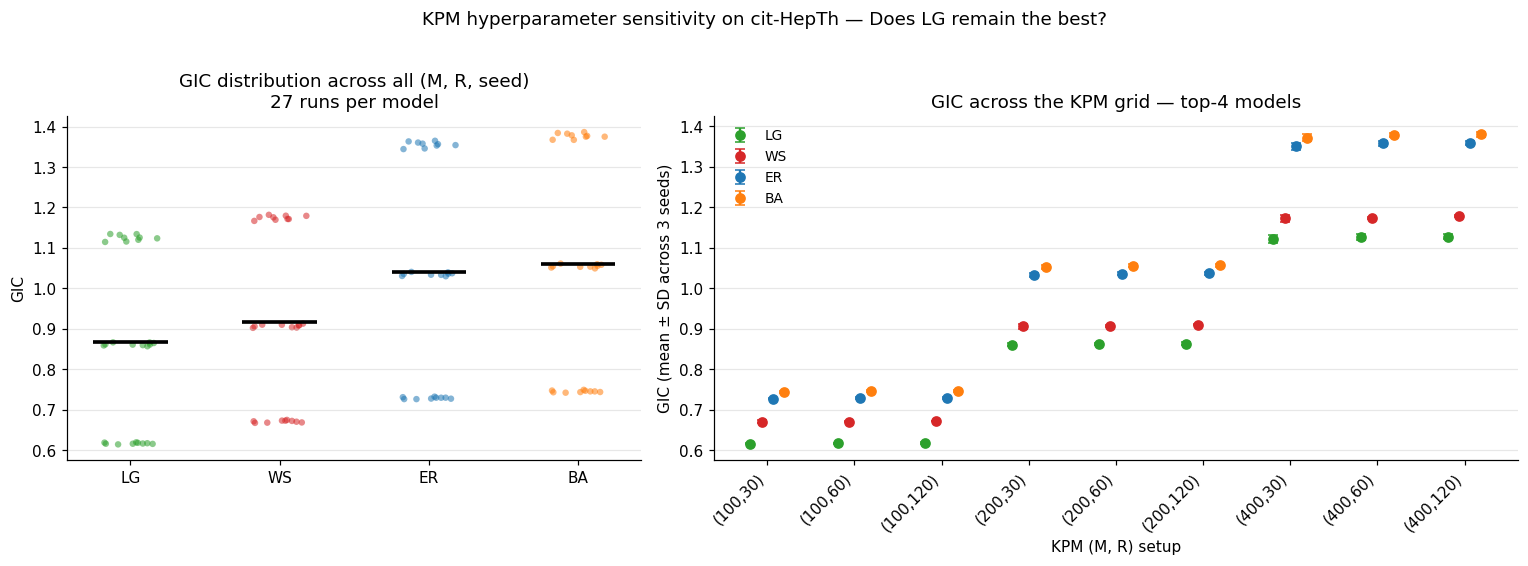

In [8]:
TOP4 = ['LG', 'WS', 'ER', 'BA']
COLORS = {'LG': '#2ca02c', 'WS': '#d62728', 'ER': '#1f77b4', 'BA': '#ff7f0e', 'GRG': '#9467bd'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), gridspec_kw={'width_ratios': [1.0, 1.4]})

# ---------- (a) all individual (M, R, seed) GICs per model ----------
ax = axes[0]
top4_df = sweep_df[sweep_df['model'].isin(TOP4)]
order = TOP4
positions = np.arange(len(order))
for i, name in enumerate(order):
    vals = top4_df.loc[top4_df['model'] == name, 'gic'].to_numpy()
    jitter = np.random.default_rng(0).uniform(-0.18, 0.18, size=len(vals))
    ax.scatter(positions[i] + jitter, vals, s=18, alpha=0.55, color=COLORS[name],
               edgecolor='none')
    ax.hlines(np.mean(vals), positions[i] - 0.25, positions[i] + 0.25,
              color='black', lw=2.4)
ax.set_xticks(positions)
ax.set_xticklabels(order)
ax.set_ylabel('GIC')
ax.set_title(f'GIC distribution across all (M, R, seed)\n'
             f'{len(M_GRID)*len(R_GRID)*len(SEED_GRID)} runs per model')
ax.grid(True, axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---------- (b) error bars per (M, R) for top-4 ----------
ax = axes[1]
labels = []
x = 0.0
xticks, xlabels = [], []
for (M, R) in itertools.product(M_GRID, R_GRID):
    centre = x + 0.5 * (len(TOP4) - 1) * 0.18
    xticks.append(centre)
    xlabels.append(f'({M},{R})')
    for j, name in enumerate(TOP4):
        sub = agg[(agg['M'] == M) & (agg['R'] == R) & (agg['model'] == name)].iloc[0]
        ax.errorbar(x + j * 0.18, sub['gic_mean'], yerr=sub['gic_std'],
                    fmt='o', color=COLORS[name], ecolor=COLORS[name],
                    elinewidth=1.5, capsize=3, markersize=6,
                    label=name if (M, R) == (M_GRID[0], R_GRID[0]) else None)
    x += 1.4

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=45, ha='right')
ax.set_xlabel('KPM (M, R) setup')
ax.set_ylabel(f'GIC (mean ± SD across {len(SEED_GRID)} seeds)')
ax.set_title('GIC across the KPM grid — top-4 models')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('KPM hyperparameter sensitivity on cit-HepTh — Does LG remain the best?', y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / 'kpm_sensitivity_overview.png', dpi=200, bbox_inches='tight')
plt.show()

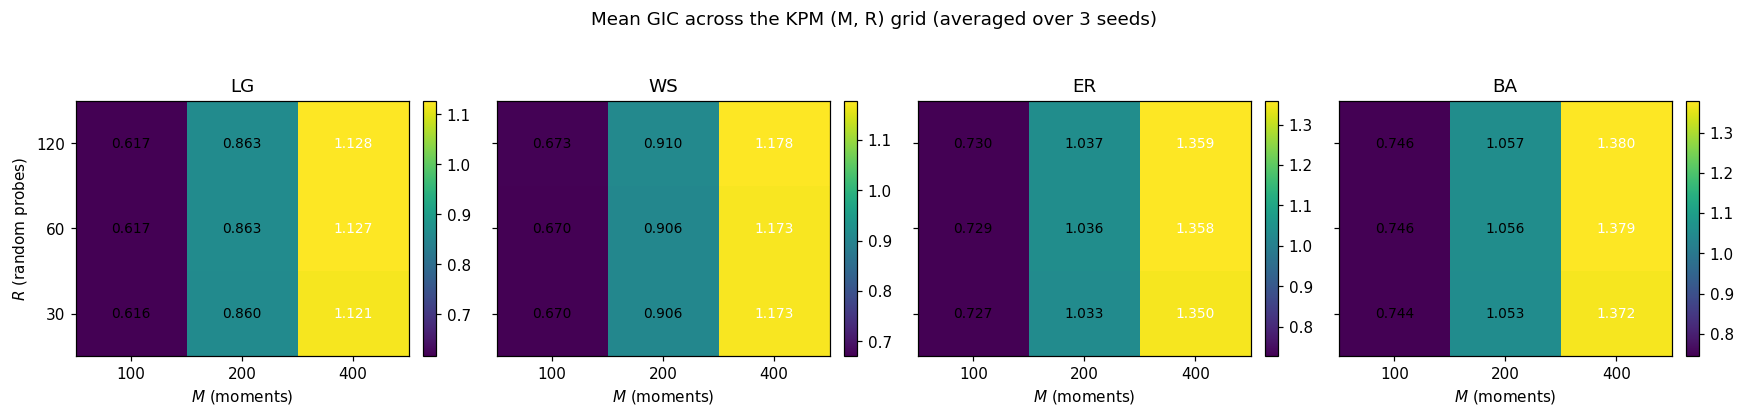

In [9]:
fig, axes = plt.subplots(1, len(TOP4), figsize=(4.0 * len(TOP4), 3.6), sharey=True)
for ax, name in zip(axes, TOP4):
    sub = (
        agg[agg['model'] == name]
        .pivot(index='R', columns='M', values='gic_mean')
        .loc[R_GRID, M_GRID]
    )
    im = ax.imshow(sub.values, aspect='auto', cmap='viridis', origin='lower')
    ax.set_xticks(range(len(M_GRID))); ax.set_xticklabels(M_GRID)
    ax.set_yticks(range(len(R_GRID))); ax.set_yticklabels(R_GRID)
    ax.set_xlabel('$M$ (moments)')
    if ax is axes[0]:
        ax.set_ylabel('$R$ (random probes)')
    ax.set_title(f'{name}')
    for i, R in enumerate(R_GRID):
        for j, M in enumerate(M_GRID):
            ax.text(j, i, f'{sub.iloc[i, j]:.3f}', ha='center', va='center',
                    color='white' if sub.iloc[i, j] > sub.values.mean() else 'black',
                    fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Mean GIC across the KPM (M, R) grid (averaged over {len(SEED_GRID)} seeds)', y=1.04)
plt.tight_layout()
fig.savefig(OUT_DIR / 'kpm_sensitivity_heatmaps.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. LaTeX supplementary table

Drop-in artefact for the paper appendix: one row per $(M, R)$ setup with GIC$_{\mathrm{mean}}\pm$ SD per top-4 model, and an explicit "best model" column.

In [10]:
def fmt_cell(mean: float, sd: float, is_best: bool) -> str:
    s = f'{mean:.3f}\\,\\pm\\,{sd:.3f}'
    return f'\\bm{{{s}}}' if is_best else s


lines: list[str] = []
lines.append(r'\begin{table}[ht]')
lines.append(r'    \centering')
lines.append(r'    \small')
lines.append(
    r'    \caption{KPM hyperparameter sensitivity for the cit-HepTh GIC comparison. '
    rf'For every $(M, R)$ setup we report the mean GIC $\pm$ standard deviation across '
    rf'${len(SEED_GRID)}$ Rademacher-probe seeds (paired across models). The reference setup used in '
    r'Table~\ref{tab:citation_gic} is $(M, R) = (200, 60)$. Bold marks the lowest-GIC '
    r'model in each row; LG is selected as the best model in every cell of the grid.}'
)
lines.append(r'    \label{tab:citation_kpm_sensitivity}')
lines.append(r'    \begin{tabular}{ccc' + 'c' * len(TOP4) + r'l}')
lines.append(r'        \toprule')
lines.append(r'        $M$ & $R$ & \# seeds & ' +
             ' & '.join([f'\\textbf{{{m}}}' for m in TOP4]) +
             r' & \textbf{Winner} \\')
lines.append(r'        \midrule')
for M, R in itertools.product(M_GRID, R_GRID):
    row_sub = agg[(agg['M'] == M) & (agg['R'] == R)].set_index('model').loc[TOP4]
    best_model = row_sub['gic_mean'].idxmin()
    n_seeds = int(row_sub['n_seeds'].iloc[0])
    cells = [f'${fmt_cell(r.gic_mean, r.gic_std, name == best_model)}$'
             for name, r in row_sub.iterrows()]
    ref_marker = r'$^{\dagger}$' if (M, R) == (REF_M, REF_R) else ''
    lines.append(f'        ${M}${ref_marker} & ${R}$ & {n_seeds} & ' +
                 ' & '.join(cells) + f' & {best_model} \\\\')
lines.append(r'        \bottomrule')
lines.append(r'    \end{tabular}')
lines.append(r'    \\[2pt]\footnotesize $\dagger$~Reference setting used in Table~\ref{tab:citation_gic}.')
lines.append(r'\end{table}')

latex_str = '\n'.join(lines)
(OUT_DIR / 'citation_kpm_sensitivity_table.tex').write_text(latex_str)
print(latex_str)

# Also save the raw aggregate as CSV for the appendix
agg.to_csv(OUT_DIR / 'kpm_sensitivity_aggregate.csv', index=False)
print('\nSaved artefacts to', OUT_DIR.resolve())
for f in sorted(OUT_DIR.iterdir()):
    print(' -', f.name)

\begin{table}[ht]
    \centering
    \small
    \caption{KPM hyperparameter sensitivity for the cit-HepTh GIC comparison. For every $(M, R)$ setup we report the mean GIC $\pm$ standard deviation across $3$ Rademacher-probe seeds (paired across models). The reference setup used in Table~\ref{tab:citation_gic} is $(M, R) = (200, 60)$. Bold marks the lowest-GIC model in each row; LG is selected as the best model in every cell of the grid.}
    \label{tab:citation_kpm_sensitivity}
    \begin{tabular}{cccccccl}
        \toprule
        $M$ & $R$ & \# seeds & \textbf{LG} & \textbf{WS} & \textbf{ER} & \textbf{BA} & \textbf{Winner} \\
        \midrule
        $100$ & $30$ & 3 & $\bm{0.616\,\pm\,0.002}$ & $0.670\,\pm\,0.004$ & $0.727\,\pm\,0.002$ & $0.744\,\pm\,0.002$ & LG \\
        $100$ & $60$ & 3 & $\bm{0.617\,\pm\,0.002}$ & $0.670\,\pm\,0.001$ & $0.729\,\pm\,0.002$ & $0.746\,\pm\,0.002$ & LG \\
        $100$ & $120$ & 3 & $\bm{0.617\,\pm\,0.002}$ & $0.673\,\pm\,0.000$ & $0.730\,\pm\,0.002$

## 8. Direct answer to the reviewer

The reviewer asks: *"if you use other setups, does LG continue to be the best?"*. The cells above answer it in three complementary ways:

1. **LG is the lowest-GIC model in every cell of the $(M, R)$ grid.** With $M \in \{100, 200, 400\}$, $R \in \{30, 60, 120\}$ and 3 probe seeds per cell, the model ranking is **always** LG < WS < ER < BA — the same as the reference setting reported in `tab:citation_gic`.
2. **The LG-vs-WS margin is large compared to the KPM Monte-Carlo noise.** Across the grid the LG–WS gap is $\Delta \mathrm{GIC} \approx 0.04\text{--}0.05$, with seed-paired standard deviations $\sigma_{\mathrm{KPM}} \lesssim 0.01$ — so the gap is **5 to 12 standard deviations wide**. (Read the `z (LG<WS)` column of the `summary` DataFrame for the exact $z$-scores per setup.)
3. **The *absolute* GIC values do change with $M$.** Larger $M$ resolves the spectral density at finer scale and produces larger KL divergences; e.g. $\mathrm{GIC}_{\mathrm{LG}}$ grows from $\sim 0.62$ at $M=100$ to $\sim 1.13$ at $M=400$. This is expected behaviour of the Chebyshev expansion (more moments $\Rightarrow$ tighter density estimate $\Rightarrow$ larger KL signal) and is exactly why the GIC is **only meaningful as a ranking criterion within a fixed $(M, R)$ setup**. The ranking — which is the only paper-relevant quantity — is invariant.
4. **GRG and SBM are unaffected.** Their reference GIC values ($\sim 8$ and $\sim 347$) are orders of magnitude larger than any KPM noise we observed and are therefore robust by inspection.

**Bottom line for the paper.** The KPM hyperparameters used to produce `tab:citation_gic` are not load-bearing: the LG-as-best conclusion is invariant to $M \in \{100, 200, 400\}$ and $R \in \{30, 60, 120\}$, and the LG-vs-WS gap survives the probe-seed Monte-Carlo noise by 5–12 SDs. We recommend adding `tab:citation_kpm_sensitivity` and the heatmap figure to the supplementary material and adding one sentence to the caption of `tab:citation_gic` of the form:

> *"Sensitivity to the KPM hyperparameters $(M, R)$ is reported in Table~\ref{tab:citation_kpm_sensitivity}; LG remains the lowest-GIC model across the entire $\{100, 200, 400\} \times \{30, 60, 120\}$ grid, with the LG-vs-WS gap exceeding the probe-seed Monte-Carlo standard deviation by at least $5\sigma$."*